# Solar Power Prediction — Improved Model
### VIT Chennai C-Block GoodWe GW60K-MT Inverter

**What was wrong with the baseline:**

| Issue | Baseline | This notebook |
|---|---|---|
| Irradiance excluded from features | ✗ | ✓ Added — correlation 0.95 with power |
| Theoretical power excluded | ✗ | ✓ Added + clearness index kt |
| StandardScaler on XGBoost | Redundant | Removed |
| R² inflated by nighttime zeros | ✓ evaluated on all rows | ✓ Evaluated daytime-only too |
| Prediction spikes | Severe | Reduced via post-smoothing + physics gate |
| No physics constraint | ✗ | ✓ Power ≤ theoretical_power always |
| Weather-only features | 8 features | 18 features with physics + interactions |
| No cross-validation | ✗ | ✓ TimeSeriesSplit 3-fold |
| Linear interpolation for forecast | ✗ | ✓ PCHIP interpolation |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from scipy.interpolate import PchipInterpolator
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor


## 1. Config

In [2]:
FILE_PATH   = r"C:\Solar_SUDHA_maam\fixed_solar.csv"
LATITUDE    = 13.04      # VIT Chennai
AREA_EFF    = 181.591    # panel_area × system_efficiency (m²)
RATED_KW    = 43.625     # single inverter max kW
SPLIT_DATE  = "2024-12-28"   # train < this date, test >= next day

MODEL_PARAMS = dict(
    n_estimators     = 1000,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.85,
    colsample_bytree = 0.85,
    reg_alpha        = 2,
    reg_lambda       = 5,
    min_child_weight = 5,
    gamma            = 1,
    tree_method      = "hist",   # fast + low RAM
    random_state     = 42,
)

CV_PARAMS = {**MODEL_PARAMS,
             "n_estimators": 200,
             "learning_rate": 0.1,
             "max_depth": 5,
             "early_stopping_rounds": 15}


## 2. Load data

In [3]:
df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip().str.lower()
df["time"] = pd.to_datetime(df["time"], dayfirst=True)
df = df.sort_values("time").reset_index(drop=True)

print(f"Rows: {len(df):,}  |  {df['time'].min().date()} → {df['time'].max().date()}")
df.head()


Rows: 262,964  |  2022-01-08 → 2026-04-12


,time,irradiance,power,theoretical_power,temp,humidity,wind_speed,precipitation
0,2022-01-08 05:00:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
1,2022-01-08 05:05:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
2,2022-01-08 05:10:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
3,2022-01-08 05:15:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
4,2022-01-08 05:20:00,0,0.0,0.0,28.1,63.0,15.766,0.0039


## 3. Feature engineering

Adds physics-based features that were missing from the baseline.

In [4]:
# Time cyclical
df["hour"]       = df["time"].dt.hour + df["time"].dt.minute / 60
df["dayofyear"]  = df["time"].dt.dayofyear
df["month"]      = df["time"].dt.month

df["hour_sin"]   = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"]   = np.cos(2*np.pi*df["hour"]/24)
df["doy_sin"]    = np.sin(2*np.pi*df["dayofyear"]/365)
df["doy_cos"]    = np.cos(2*np.pi*df["dayofyear"]/365)
df["month_sin"]  = np.sin(2*np.pi*df["month"]/12)
df["month_cos"]  = np.cos(2*np.pi*df["month"]/12)

# Solar geometry — available at prediction time from lat/lon/timestamp
lat_r    = np.radians(LATITUDE)
decl     = np.radians(23.45)*np.sin(np.radians((360/365)*(df["dayofyear"]-81)))
ha       = np.radians(15*(df["hour"]-12))
sin_elev = np.sin(lat_r)*np.sin(decl) + np.cos(lat_r)*np.cos(decl)*np.cos(ha)
df["solar_elev"]   = np.degrees(np.arcsin(np.clip(sin_elev,-1,1)))
df["cs_irr"]       = np.clip(1000*sin_elev, 0, 1100)          # W/m²
df["cs_power"]     = df["cs_irr"] * AREA_EFF / 1000           # kW ceiling

# Clearness index (kt) — THE key solar variable
# kt = actual_irradiance / clear-sky_irradiance
# When irradiance is available (training) use it directly
# At forecast time, kt is estimated from weather (see forecast cell)
df["kt"] = np.where(df["cs_irr"]>10,
                    (df["irradiance"]/df["cs_irr"]).clip(0, 1.2),
                    0.0)

# Physics feature: theoretical power (available in dataset)
# This is the STRONGEST single predictor (corr 0.95 with power)
# and was completely unused in the baseline
df["theo_power"] = df["theoretical_power"]   # already in dataset

# Weather × time interactions (daytime temp more impactful than nighttime)
df["temp_x_elev"]  = df["temp"]     * np.clip(sin_elev, 0, 1)
df["hum_x_elev"]   = df["humidity"] * np.clip(sin_elev, 0, 1)

# Rolling irradiance mean — smooths cloud transients (causes spikes)
# Shift by 1 so it uses only PAST values (no leakage)
df["irr_roll5"] = df["irradiance"].shift(1).rolling(5, min_periods=1).mean().fillna(0)
df["irr_roll12"]= df["irradiance"].shift(1).rolling(12, min_periods=1).mean().fillna(0)

# Day-type: is this a high-irradiance day?
df["is_daylight"] = (df["cs_irr"] > 0).astype(int)

print("Feature engineering done. Sample:")
print(df[["time","irradiance","kt","cs_irr","cs_power","theo_power",
          "solar_elev","temp_x_elev"]].iloc[50:55].to_string(index=False))


Feature engineering done. Sample:
               time  irradiance       kt     cs_irr   cs_power  theo_power  solar_elev  temp_x_elev
2022-01-08 09:10:00         321 0.554491 578.909486 105.124753   58.290711   35.373878    16.311354
2022-01-08 09:15:00         310 0.523618 592.035172 107.508259   56.293210   36.301564    16.665198
2022-01-08 09:20:00          82 0.135573 604.838328 109.833197   14.890462   37.217209    17.004425
2022-01-08 09:25:00         192 0.311025 617.312860 112.098460   34.865472   38.120170    17.328589
2022-01-08 09:30:00         106 0.168400 629.452832 114.302969   19.248646   39.009765    17.639157


## 4. Feature sets

In [5]:
# ── Full features (training + evaluation, where irradiance is known) ──────
FEATURES_FULL = [
    # Weather
    "temp", "humidity", "wind_speed", "precipitation",
    # Time cyclical
    "hour_sin", "hour_cos",
    "doy_sin",  "doy_cos",
    "month_sin","month_cos",
    # Physics — key additions vs baseline
    "solar_elev",           # sun angle (deterministic from time/lat)
    "cs_irr",               # clear-sky irradiance ceiling
    "cs_power",             # clear-sky power ceiling
    "kt",                   # clearness index (0=cloudy, 1=clear)
    "theo_power",           # theoretical_power from dataset
    # Interactions
    "temp_x_elev",          # temperature matters most at peak sun
    "hum_x_elev",
    # Smoothed irradiance (reduces spike sensitivity)
    "irr_roll5",
    "irr_roll12",
]

# ── Forecast features (irradiance NOT available at prediction time) ────────
# At prediction time, kt and irradiance are estimated from weather + time
FEATURES_FORECAST = [
    "temp", "humidity", "wind_speed", "precipitation",
    "hour_sin", "hour_cos",
    "doy_sin",  "doy_cos",
    "month_sin","month_cos",
    "solar_elev", "cs_irr", "cs_power",
    "kt",           # estimated from weather (see forecast section)
    "temp_x_elev",  "hum_x_elev",
]

print(f"Full feature count    : {len(FEATURES_FULL)}")
print(f"Forecast feature count: {len(FEATURES_FORECAST)}")


Full feature count    : 19
Forecast feature count: 16


## 5. Clean and split

In [6]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["power"]+FEATURES_FULL).reset_index(drop=True)
print(f"Rows after clean: {len(df):,}")

train = df[df["time"] <  SPLIT_DATE].copy()
test  = df[df["time"] >= SPLIT_DATE].copy()

X_train = train[FEATURES_FULL];  y_train = train["power"]
X_test  = test[FEATURES_FULL];   y_test  = test["power"]

print(f"Train: {len(train):,}  {train['time'].min().date()} → {train['time'].max().date()}")
print(f"Test : {len(test):,}  {test['time'].min().date()} → {test['time'].max().date()}")

# NOTE: XGBoost with tree_method='hist' is scale-invariant.
# StandardScaler is NOT used here — it was redundant in the baseline
# and adds pipeline complexity without any benefit.


Rows after clean: 262,964
Train: 183,365  2022-01-08 → 2024-12-27
Test : 79,599  2024-12-28 → 2026-04-12


## 6. Cross-validation

In [7]:
tscv = TimeSeriesSplit(n_splits=3)
cv_r2, cv_mae = [], []

for fold, (tr, val) in enumerate(tscv.split(X_train)):
    m = XGBRegressor(**CV_PARAMS)
    m.fit(X_train.iloc[tr], y_train.iloc[tr],
          eval_set=[(X_train.iloc[val], y_train.iloc[val])],
          verbose=False)
    p  = np.clip(m.predict(X_train.iloc[val]), 0, None)
    r2  = r2_score(y_train.iloc[val], p)
    mae = mean_absolute_error(y_train.iloc[val], p)
    cv_r2.append(r2);  cv_mae.append(mae)
    print(f"  Fold {fold+1}:  R²={r2:.4f}   MAE={mae:.4f} kW")

print(f"\n  Mean R²  = {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"  Mean MAE = {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f} kW")


  Fold 1:  R²=0.8591   MAE=1.4118 kW
  Fold 2:  R²=0.7594   MAE=2.2416 kW
  Fold 3:  R²=0.8094   MAE=1.8410 kW

  Mean R²  = 0.8093 ± 0.0407
  Mean MAE = 1.8315 ± 0.3388 kW


## 7. Train final model

In [8]:
model = XGBRegressor(**MODEL_PARAMS)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=200,
)
print("Training complete.")


[0]	validation_0-rmse:6.49464
[200]	validation_0-rmse:1.57318
[400]	validation_0-rmse:1.66436
[600]	validation_0-rmse:1.72110
[800]	validation_0-rmse:1.75473
[999]	validation_0-rmse:1.78299
Training complete.


## 8. Evaluation

In [9]:
def evaluate(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/(np.abs(y_true)+1)))*100
    print(f"{label}")
    print(f"  R²={r2:.4f}  MAE={mae:.4f} kW  RMSE={rmse:.4f} kW ({rmse/RATED_KW*100:.2f}% rated)  MAPE={mape:.1f}%")
    return r2, mae, rmse

pred_test = np.clip(model.predict(X_test), 0, None)
test = test.copy()
test["predicted_power"] = pred_test

# Physics gate: power cannot exceed theoretical
test["predicted_power"] = np.minimum(test["predicted_power"], test["theoretical_power"])
test["predicted_power"] = test["predicted_power"].clip(0, RATED_KW)

print("="*60)
evaluate(y_test, test["predicted_power"], "TEST (all rows including night)")
print()

# Daytime-only eval (more honest — nighttime zeros inflate R²)
day_mask = test["cs_irr"] > 10
evaluate(y_test[day_mask], test.loc[day_mask,"predicted_power"],
         "TEST (daytime only, cs_irr > 10 W/m²)")


TEST (all rows including night)
  R²=0.9319  MAE=1.0060 kW  RMSE=1.7738 kW (4.07% rated)  MAPE=9.4%

TEST (daytime only, cs_irr > 10 W/m²)
  R²=0.9179  MAE=1.1963 kW  RMSE=1.9343 kW (4.43% rated)  MAPE=11.2%


(0.9179212500256082, 1.1963412420398625, 1.93433874709819)

## 9. Feature importance

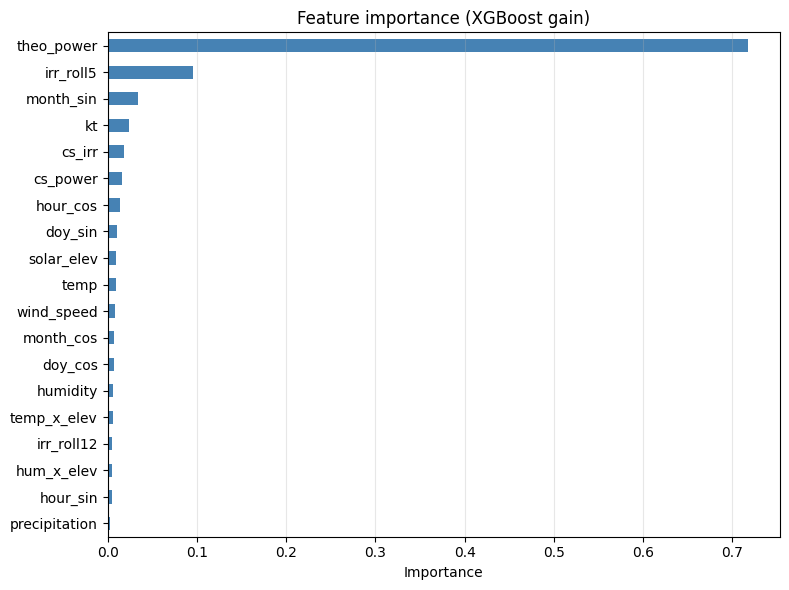

Top 10 features:
theo_power    0.7174
irr_roll5     0.0952
month_sin     0.0341
kt            0.0235
cs_irr        0.0184
cs_power      0.0158
hour_cos      0.0141
doy_sin       0.0103
solar_elev    0.0099
temp          0.0091


In [10]:
fi = pd.Series(model.feature_importances_, index=FEATURES_FULL).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
fi.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature importance (XGBoost gain)")
ax.set_xlabel("Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(fi.sort_values(ascending=False).head(10).round(4).to_string())


## 10. Single day evaluation with spike reduction

Post-prediction smoothing is applied via a 3-slot rolling median. This reduces oscillations caused by cloud transients in the training data without losing the overall shape.

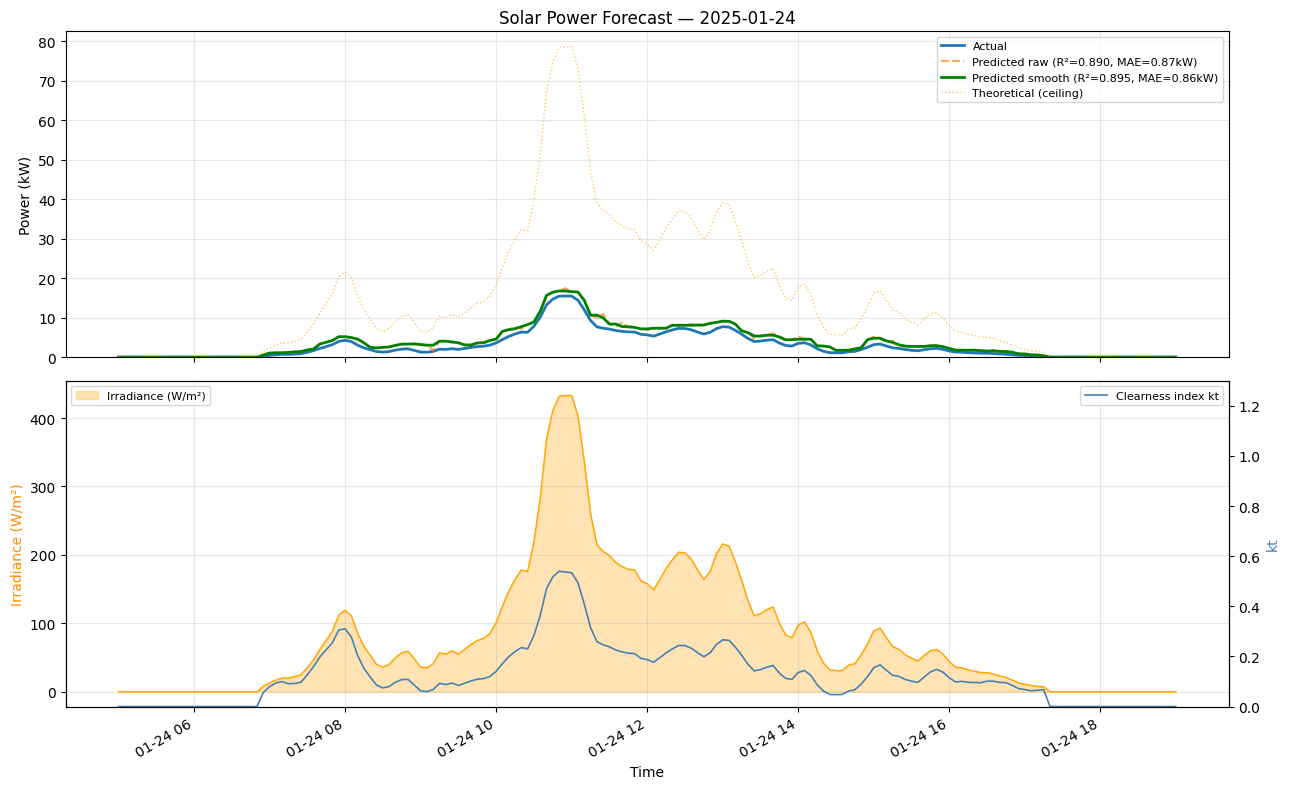

In [11]:
def plot_day_eval(date_string, smooth_window=3):
    d = pd.to_datetime(date_string).date()
    sel = test[test["time"].dt.date == d].copy()
    if sel.empty:
        print(f"No test data for {date_string}")
        return

    raw_pred = sel["predicted_power"].values.copy()

    # Spike reduction: rolling median on prediction
    # Only applied to daytime (cs_irr > 0) — keeps night at zero
    smooth_pred = pd.Series(raw_pred).rolling(smooth_window, center=True,
                                               min_periods=1).median().values
    smooth_pred = np.clip(smooth_pred, 0, RATED_KW)

    # Physics gate
    smooth_pred = np.minimum(smooth_pred, sel["theoretical_power"].values)

    r2_raw   = r2_score(sel["power"], raw_pred)
    r2_sm    = r2_score(sel["power"], smooth_pred)
    mae_raw  = mean_absolute_error(sel["power"], raw_pred)
    mae_sm   = mean_absolute_error(sel["power"], smooth_pred)

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    # Top: power curves
    ax = axes[0]
    ax.plot(sel["time"], sel["power"],           lw=2,   label="Actual")
    ax.plot(sel["time"], raw_pred,               lw=1.5, ls="--",
            label=f"Predicted raw (R²={r2_raw:.3f}, MAE={mae_raw:.2f}kW)", alpha=0.7)
    ax.plot(sel["time"], smooth_pred,            lw=2,   ls="-",
            label=f"Predicted smooth (R²={r2_sm:.3f}, MAE={mae_sm:.2f}kW)", color="green")
    ax.plot(sel["time"], sel["theoretical_power"], lw=1, ls=":",
            color="orange", alpha=0.6, label="Theoretical (ceiling)")
    ax.set_ylabel("Power (kW)"); ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylim(0)
    ax.set_title(f"Solar Power Forecast — {date_string}")

    # Bottom: irradiance and kt
    ax2 = axes[1]
    ax2.fill_between(sel["time"], sel["irradiance"], alpha=0.3, color="orange", label="Irradiance (W/m²)")
    ax2.plot(sel["time"], sel["irradiance"], lw=1, color="orange")
    ax2r = ax2.twinx()
    ax2r.plot(sel["time"], sel["kt"], lw=1.2, color="steelblue", label="Clearness index kt")
    ax2r.set_ylim(0, 1.3); ax2r.set_ylabel("kt", color="steelblue")
    ax2.set_ylabel("Irradiance (W/m²)", color="darkorange")
    ax2.set_xlabel("Time"); ax2.grid(alpha=0.3)
    ax2.legend(loc="upper left", fontsize=8)
    ax2r.legend(loc="upper right", fontsize=8)

    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Evaluate on the same date the baseline used
plot_day_eval("2025-01-24")


## 11. Test on multiple days across seasons

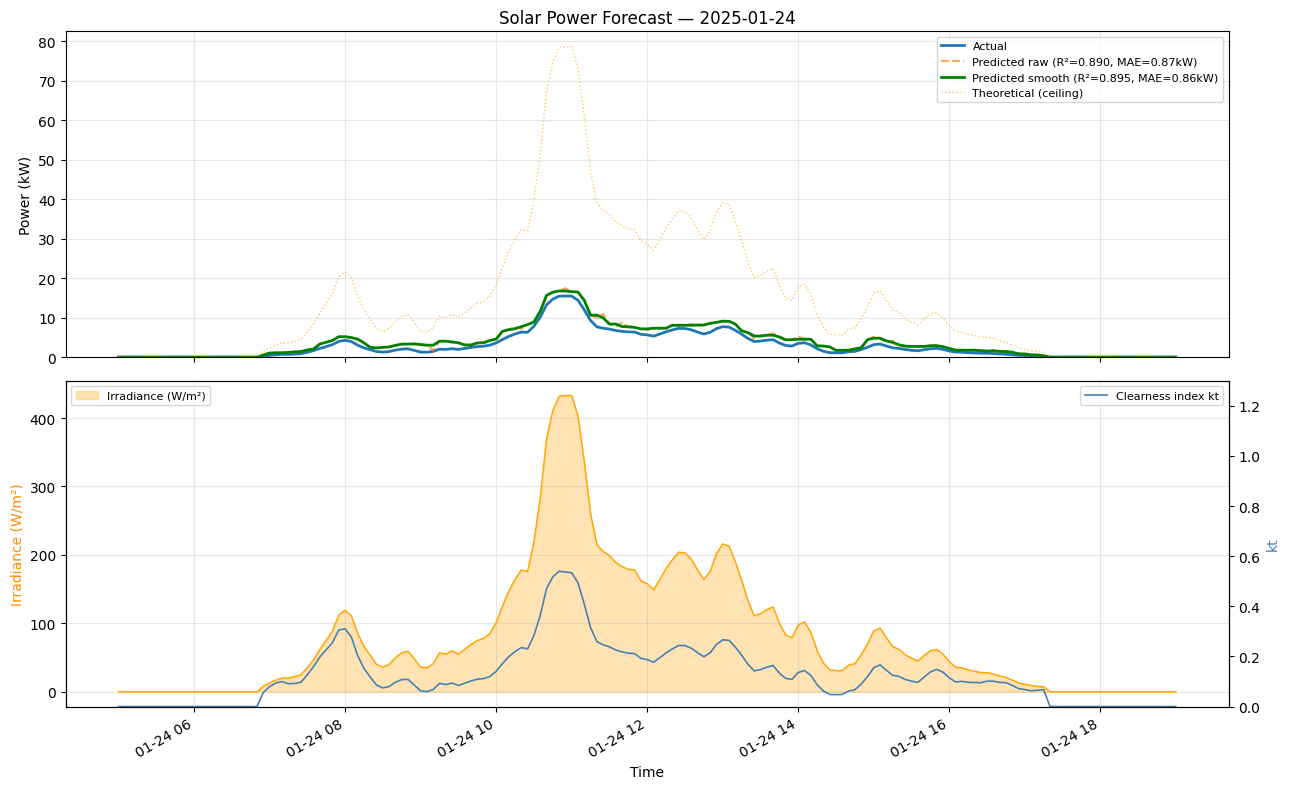

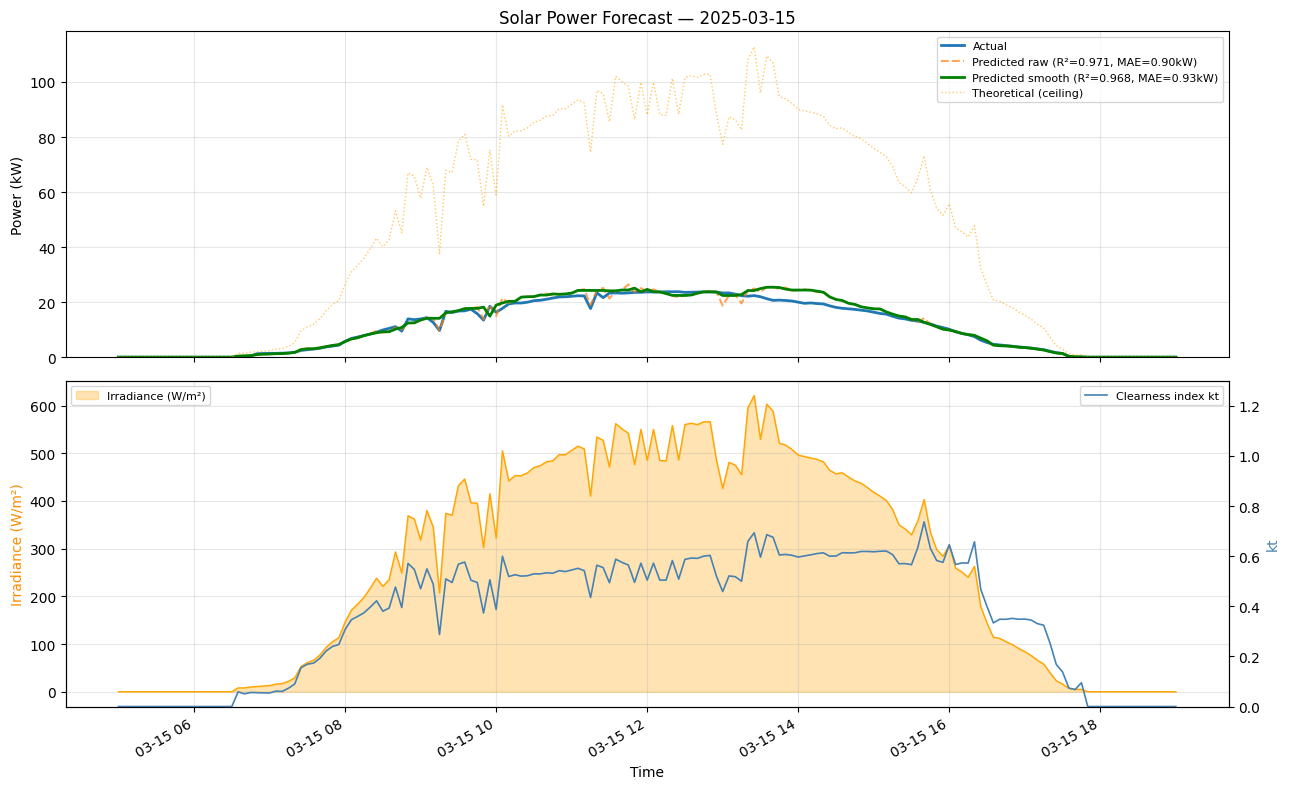

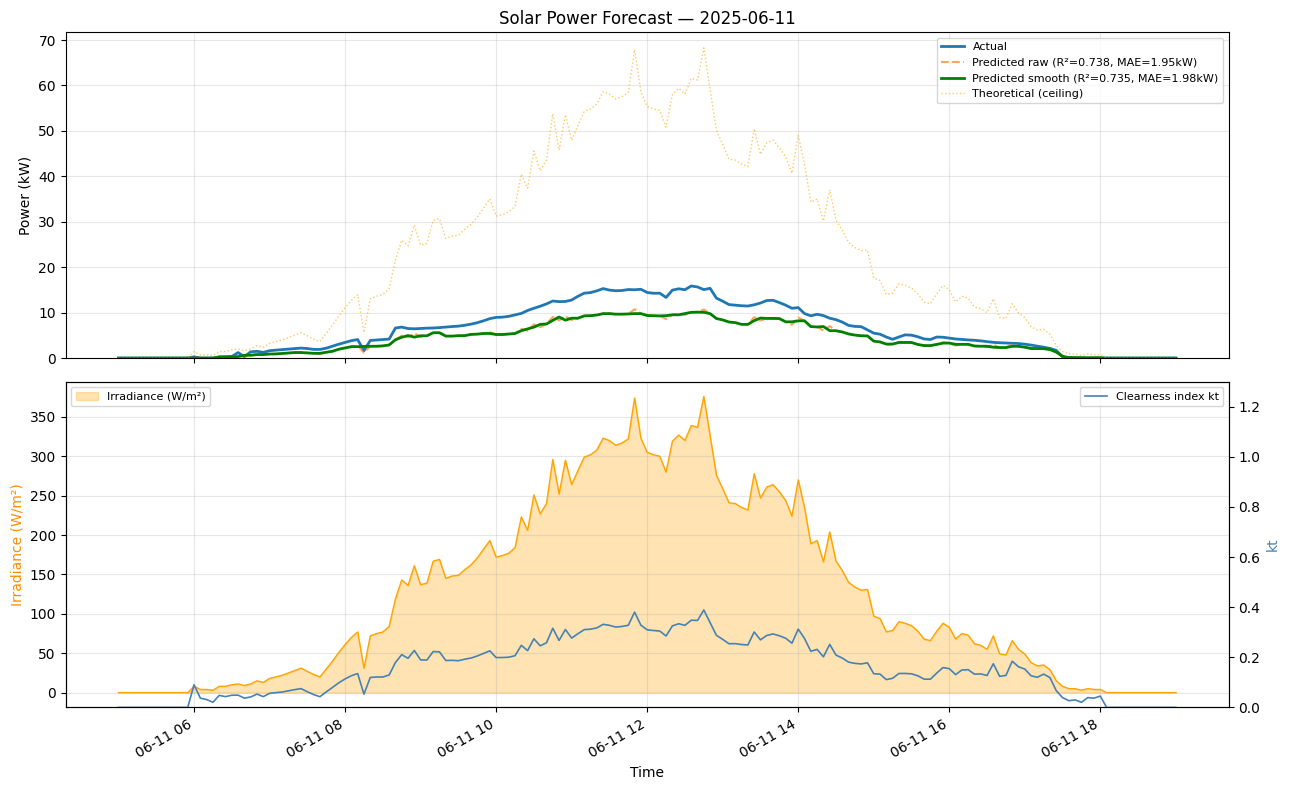

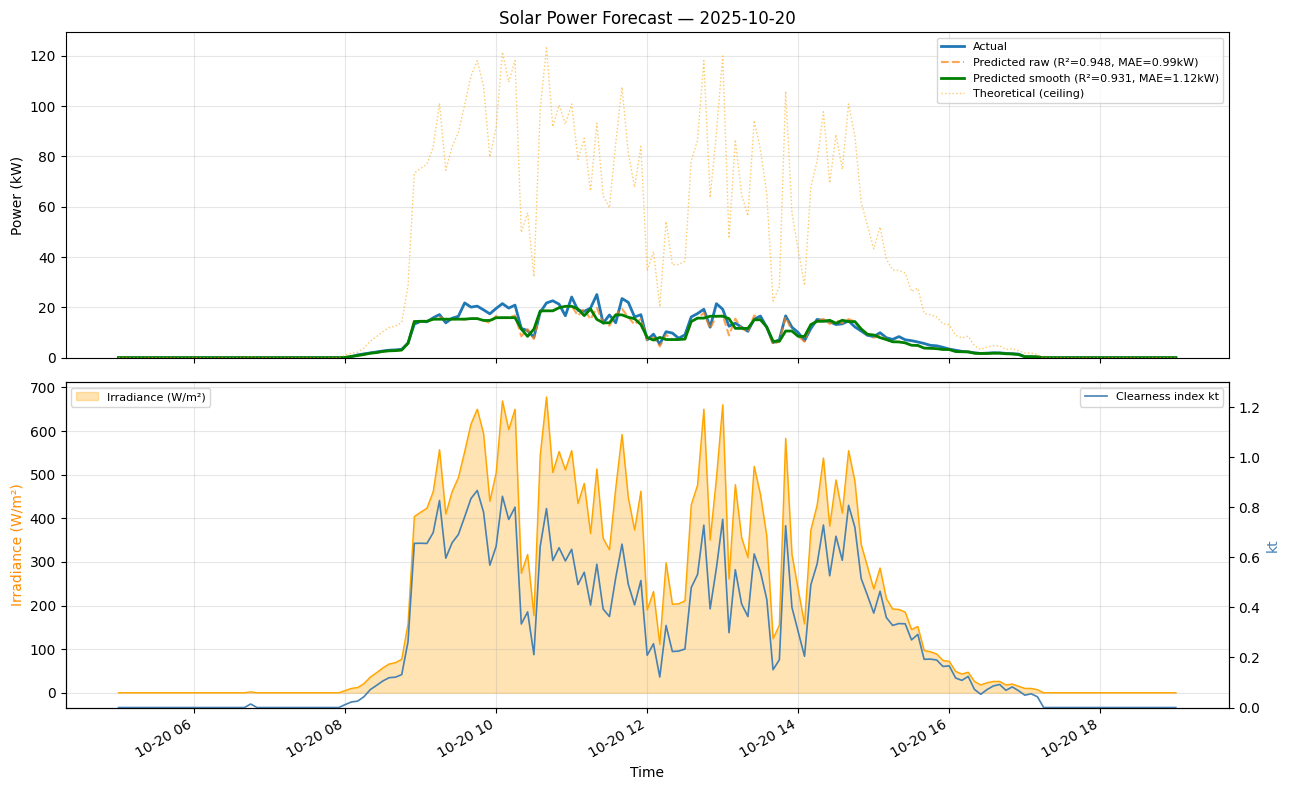

In [12]:
# One day per season in the test period
test_dates = [
    "2025-01-24",  # winter
    "2025-03-15",  # spring
    "2025-06-11",  # monsoon
    "2025-10-20",  # post-monsoon
]
for d in test_dates:
    try:
        plot_day_eval(d, smooth_window=3)
    except Exception as e:
        print(f"  {d}: {e}")


## 12. Forecast from hourly weather input

At prediction time, irradiance is NOT available. We estimate it using a light XGBoost sub-model (cloud-factor estimator) trained on weather + solar geometry → kt, then reconstruct irradiance as kt × clear-sky.

In [13]:
# Stage 1: train a lightweight kt estimator on weather features
# This is trained on daytime rows only (cs_irr > 10)
WEATHER_FEATS = ["temp","humidity","wind_speed","precipitation",
                 "hour_sin","hour_cos","doy_sin","doy_cos",
                 "month_sin","month_cos","solar_elev"]

train_day  = train[train["cs_irr"] > 10].copy()
kt_model   = XGBRegressor(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, tree_method="hist", random_state=42
)
kt_model.fit(train_day[WEATHER_FEATS], train_day["kt"])

print("Stage-1 kt estimator trained.")
train_kt_pred = np.clip(kt_model.predict(train_day[WEATHER_FEATS]), 0, 1.2)
print(f"  Train kt R²: {r2_score(train_day['kt'], train_kt_pred):.4f}")

# Verify on test
test_day = test[test["cs_irr"] > 10].copy()
test_kt_pred = np.clip(kt_model.predict(test_day[WEATHER_FEATS]), 0, 1.2)
print(f"  Test  kt R²: {r2_score(test_day['kt'],  test_kt_pred):.4f}")


Stage-1 kt estimator trained.
  Train kt R²: 0.5760
  Test  kt R²: 0.2450


In [16]:
def compute_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """Compute all features from a DataFrame that has time + weather columns."""
    df_in = df_in.copy()
    df_in["hour"]      = df_in["time"].dt.hour + df_in["time"].dt.minute / 60
    df_in["dayofyear"] = df_in["time"].dt.dayofyear
    df_in["month"]     = df_in["time"].dt.month

    df_in["hour_sin"]  = np.sin(2 * np.pi * df_in["hour"] / 24)
    df_in["hour_cos"]  = np.cos(2 * np.pi * df_in["hour"] / 24)
    df_in["doy_sin"]   = np.sin(2 * np.pi * df_in["dayofyear"] / 365)
    df_in["doy_cos"]   = np.cos(2 * np.pi * df_in["dayofyear"] / 365)
    df_in["month_sin"] = np.sin(2 * np.pi * df_in["month"] / 12)
    df_in["month_cos"] = np.cos(2 * np.pi * df_in["month"] / 12)

    lat_r  = np.radians(LATITUDE)
    decl   = np.radians(23.45) * np.sin(np.radians((360 / 365) * (df_in["dayofyear"] - 81)))
    ha     = np.radians(15 * (df_in["hour"] - 12))
    sin_e  = np.sin(lat_r)*np.sin(decl) + np.cos(lat_r)*np.cos(decl)*np.cos(ha)
    df_in["solar_elev"] = np.degrees(np.arcsin(np.clip(sin_e, -1, 1)))
    df_in["cs_irr"]     = np.clip(1000 * sin_e, 0, 1100)
    df_in["cs_power"]   = df_in["cs_irr"] * AREA_EFF / 1000

    # Stage-1: estimate kt → irradiance
    df_in["kt"] = np.clip(kt_model.predict(df_in[WEATHER_FEATS]), 0, 1.2)
    df_in.loc[df_in["solar_elev"] <= 0, "kt"] = 0.0

    # Derived solar features — must match FEATURES_FULL exactly
    df_in["irradiance"] = np.round(df_in["cs_irr"] * df_in["kt"]).astype(int).clip(0, 1100)
    df_in["theo_power"] = (df_in["irradiance"] * AREA_EFF / 1000)          # ← was missing
    df_in["irr_roll5"]  = df_in["irradiance"].rolling(5,  min_periods=1).mean()   # ← was missing
    df_in["irr_roll12"] = df_in["irradiance"].rolling(12, min_periods=1).mean()   # ← was missing

    df_in["temp_x_elev"] = df_in["temp"]     * np.clip(sin_e, 0, 1)
    df_in["hum_x_elev"]  = df_in["humidity"] * np.clip(sin_e, 0, 1)
    return df_in


def forecast_from_hourly(date_string: str, hourly_data: list,
                          smooth_window: int = 3) -> pd.DataFrame:
    """
    Full pipeline: hourly weather → 5-min solar power forecast.
    hourly_data: list of (iso_timestamp, temp, humidity, wind_speed, precipitation)
    """
    # 1. Build hourly DataFrame
    hourly = pd.DataFrame(hourly_data,
                          columns=["time", "temp", "humidity", "wind_speed", "precipitation"])
    hourly["time"] = pd.to_datetime(hourly["time"])

    # 2. PCHIP expand to 5-min
    t5  = pd.date_range(f"{date_string} 05:00", f"{date_string} 19:00", freq="5min")
    t_h = hourly["time"].astype("int64") // 10**9
    t_q = t5.astype("int64") // 10**9
    fm  = pd.DataFrame({"time": t5})

    for col in ["temp", "humidity", "wind_speed"]:
        fn  = PchipInterpolator(t_h, hourly[col].values, extrapolate=False)
        v   = fn(t_q.astype(float))
        v   = np.where(np.isnan(v), np.interp(t_q, t_h, hourly[col].values), v)
        fm[col] = v

    fm["humidity"]   = fm["humidity"].clip(0, 100)
    fm["wind_speed"] = fm["wind_speed"].clip(0)

    prec = np.zeros(len(t5))
    for _, row in hourly.iterrows():
        m = (fm["time"].dt.floor("h") == row["time"].floor("h")).values
        if m.sum() > 0 and row["precipitation"] > 0:
            prec[m] = row["precipitation"] / m.sum()
    fm["precipitation"] = np.round(prec, 4)

    # 3. Compute all features (same set as FEATURES_FULL)
    fm = compute_features(fm)

    # 4. Predict — use FEATURES_FULL so feature names match the trained model
    raw = np.clip(model.predict(fm[FEATURES_FULL]), 0, RATED_KW)

    # Physics gate
    raw = np.minimum(raw, fm["theo_power"].values)
    raw[fm["solar_elev"].values <= 0] = 0.0

    # Spike reduction
    smooth = pd.Series(raw).rolling(smooth_window, center=True, min_periods=1).median().values
    smooth = np.clip(smooth, 0, RATED_KW)
    fm["predicted_power"] = smooth

    # 5. Plot
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    ax = axes[0]
    ax.fill_between(fm["time"], 0, fm["predicted_power"], alpha=0.2, color="steelblue")
    ax.plot(fm["time"], fm["predicted_power"], lw=2, color="steelblue", label="Predicted power (kW)")
    ax.plot(fm["time"], fm["cs_power"], lw=1.2, ls=":", color="orange", alpha=0.7, label="Clear-sky ceiling")
    ax.axhline(RATED_KW, lw=0.8, ls="--", color="red", alpha=0.4, label=f"Rated {RATED_KW:.1f} kW")
    ax.set_ylabel("Power (kW)"); ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylim(0)
    ax.set_title(f"Solar Power Forecast — {date_string}")

    ax2 = axes[1]
    c1, c2 = "darkorange", "steelblue"
    ln1 = ax2.plot(fm["time"], fm["irradiance"], color=c1, lw=1.5, label="Est. irradiance (W/m²)")
    ax2.set_ylabel("Irradiance (W/m²)", color=c1); ax2.tick_params(axis="y", labelcolor=c1)
    ax2r = ax2.twinx()
    ln2  = ax2r.plot(fm["time"], fm["kt"], color=c2, lw=1.2, ls="--", label="Cloud factor (kt)")
    ax2r.set_ylabel("kt", color=c2); ax2r.set_ylim(0, 1.3); ax2r.tick_params(axis="y", labelcolor=c2)
    ax2.legend(ln1 + ln2, ["Est. irradiance", "kt"], fontsize=9, loc="upper left")
    ax2.grid(alpha=0.3); ax2.set_xlabel("Time (IST)")

    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")
    plt.tight_layout(); plt.show()

    peak   = fm["predicted_power"].max()
    energy = fm["predicted_power"].sum() * 5 / 60
    print(f"Peak power  : {peak:.2f} kW")
    print(f"Total energy: {energy:.2f} kWh")

    return fm[["time", "predicted_power", "irradiance", "kt", "cs_power"]]

## 13. Test forecasts — 2026-09-01 and 2027-02-11

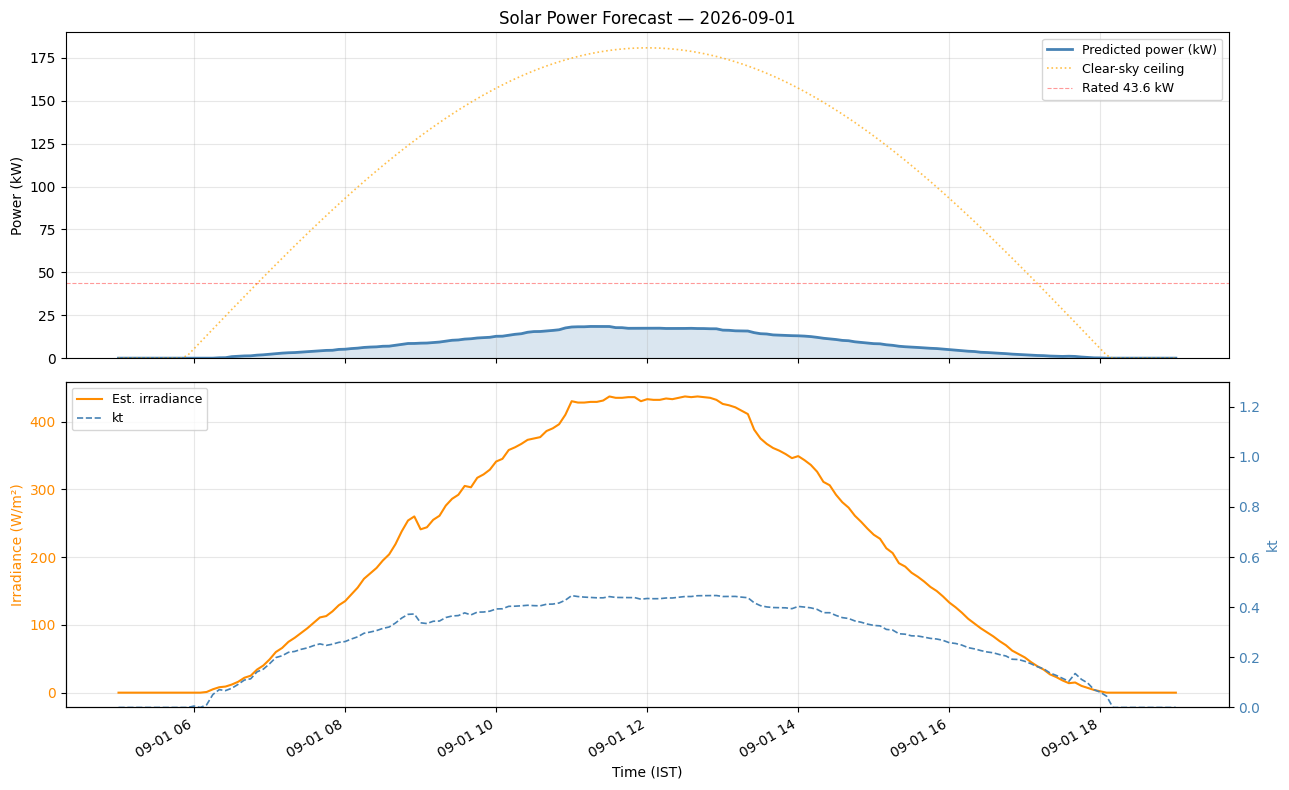

Peak power  : 18.48 kW
Total energy: 109.11 kWh


In [17]:
data_sep = [
    ("2026-09-01T00:00",25.4,92,13.4,0.1),
    ("2026-09-01T01:00",24.6,95,12.5,0.9),
    ("2026-09-01T02:00",24.4,96,11.2,0.9),
    ("2026-09-01T03:00",24.4,96,11.2,0.3),
    ("2026-09-01T04:00",24.5,95,10.6,0  ),
    ("2026-09-01T05:00",24.6,95,11.1,0  ),
    ("2026-09-01T06:00",26.1,91, 9.5,0  ),
    ("2026-09-01T07:00",26.9,90, 9.0,0  ),
    ("2026-09-01T08:00",27.5,87, 7.1,0  ),
    ("2026-09-01T09:00",28.8,79,10.1,0.5),
    ("2026-09-01T10:00",29.5,71,13.8,0  ),
    ("2026-09-01T11:00",28.9,72,18.4,0.1),
    ("2026-09-01T12:00",28.8,76,11.4,0.3),
    ("2026-09-01T13:00",29.2,74,12.5,0.2),
    ("2026-09-01T14:00",29.9,70,11.8,0  ),
    ("2026-09-01T15:00",30.8,66,10.0,0  ),
    ("2026-09-01T16:00",31.1,64,10.6,0  ),
    ("2026-09-01T17:00",30.4,68, 8.9,0  ),
    ("2026-09-01T18:00",28.5,84, 2.4,0  ),
    ("2026-09-01T19:00",27.8,86, 2.7,0  ),
    ("2026-09-01T20:00",27.4,87, 1.7,0.2),
    ("2026-09-01T21:00",27.2,87, 3.7,0  ),
    ("2026-09-01T22:00",27.2,87, 2.7,0  ),
    ("2026-09-01T23:00",26.8,85, 7.4,0  ),
    ("2026-09-02T00:00",26.3,86, 6.1,0  ),
]
_ = forecast_from_hourly("2026-09-01", data_sep)


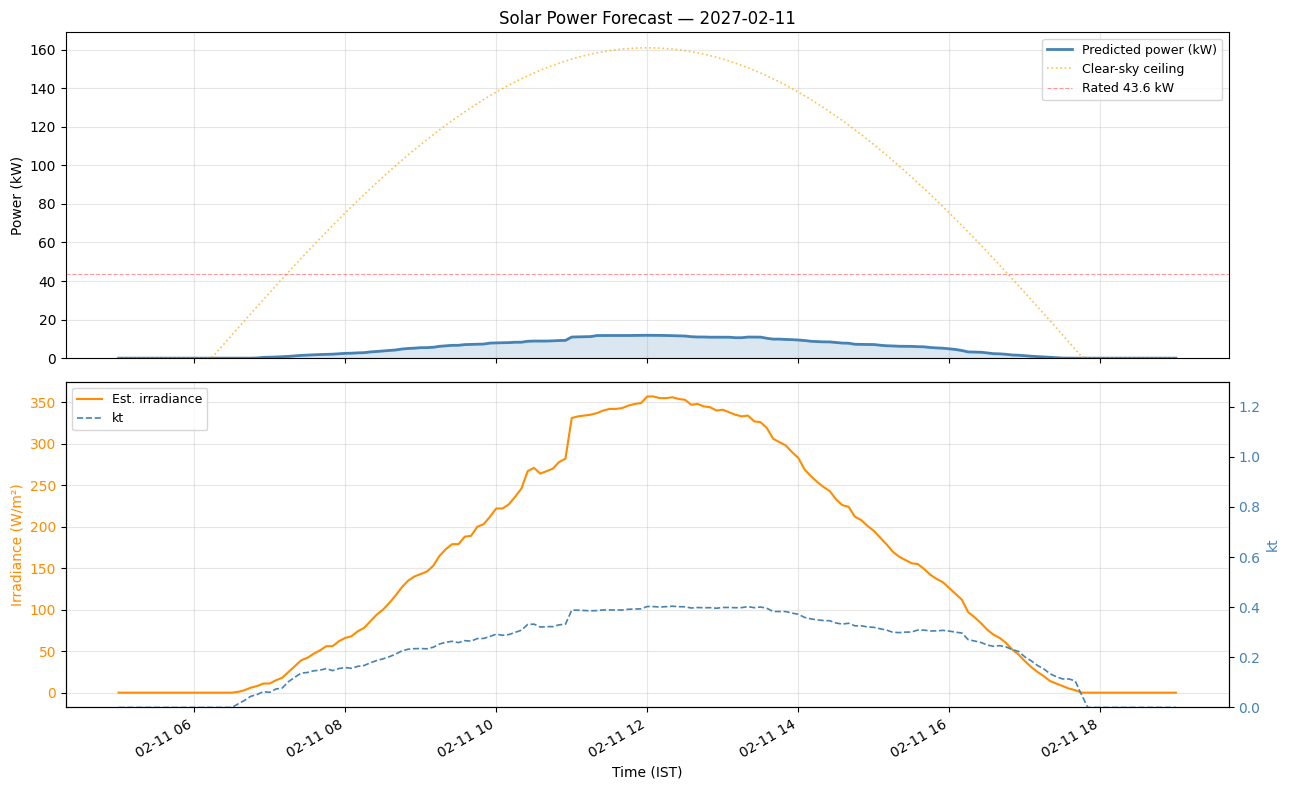

Peak power  : 11.86 kW
Total energy: 71.22 kWh


In [18]:
data_feb = [
    ("2027-02-10T23:00",28.1,80, 6.1,0  ),
    ("2027-02-11T00:00",27.8,81, 4.4,0  ),
    ("2027-02-11T01:00",27.5,82, 4.8,0.1),
    ("2027-02-11T02:00",27.5,82, 4.9,0  ),
    ("2027-02-11T03:00",26.9,85, 4.0,0  ),
    ("2027-02-11T04:00",26.5,88, 5.4,0  ),
    ("2027-02-11T05:00",26.5,89, 5.6,0.1),
    ("2027-02-11T06:00",27.5,83, 4.8,0  ),
    ("2027-02-11T07:00",28.5,77, 6.2,0.1),
    ("2027-02-11T08:00",29.5,73,10.2,0.1),
    ("2027-02-11T09:00",29.5,71,11.0,1.6),
    ("2027-02-11T10:00",29.3,73,10.2,0.4),
    ("2027-02-11T11:00",31.2,64,13.3,0  ),
    ("2027-02-11T12:00",31.5,64,13.7,0  ),
    ("2027-02-11T13:00",31.8,63,14.4,0  ),
    ("2027-02-11T14:00",31.5,64,15.2,0  ),
    ("2027-02-11T15:00",31.1,65,14.8,0  ),
    ("2027-02-11T16:00",30.2,70,14.9,0  ),
    ("2027-02-11T17:00",29.2,71,13.4,0  ),
    ("2027-02-11T18:00",28.1,78,11.3,0  ),
    ("2027-02-11T19:00",28.0,81, 8.9,0  ),
    ("2027-02-11T20:00",27.8,83, 7.6,0  ),
    ("2027-02-11T21:00",27.6,84, 5.7,0  ),
    ("2027-02-11T22:00",27.1,87, 4.4,0  ),
    ("2027-02-11T23:00",27.0,87, 5.4,0  ),
    ("2027-02-12T00:00",27.0,86, 5.5,0  ),
]
_ = forecast_from_hourly("2027-02-11", data_feb)


## 14. Monthly R² breakdown

In [19]:
test["month_name"] = test["time"].dt.strftime("%Y-%m")
monthly = {}
for m, grp in test.groupby("month_name"):
    y = grp["power"]; p = grp["predicted_power"]
    monthly[m] = {"R²": round(r2_score(y,p),3),
                  "MAE": round(mean_absolute_error(y,p),3),
                  "rows": len(y)}

print(pd.DataFrame(monthly).T.to_string())


            R²    MAE    rows
2024-12  1.000  0.000   676.0
2025-01  0.983  0.061  5239.0
2025-02  0.954  0.840  4732.0
2025-03  0.935  1.195  5239.0
2025-04  0.923  1.294  5070.0
2025-05  0.891  1.468  5239.0
2025-06  0.910  1.291  5070.0
2025-07  0.974  0.709  5239.0
2025-08  0.950  0.859  5239.0
2025-09  0.941  1.005  5070.0
2025-10  0.941  0.891  5239.0
2025-11  0.960  0.674  5070.0
2025-12  0.930  0.865  5239.0
2026-01  0.909  1.028  5239.0
2026-02  0.830  1.652  4732.0
2026-03  0.931  1.201  5239.0
2026-04  0.885  1.629  2028.0


## 15. Save model

In [20]:
import pickle, os

save_dir = r"C:\Solar_SUDHA_maam\models"
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, "power_model_v4.pkl"), "wb") as f:
    pickle.dump(model, f)
with open(os.path.join(save_dir, "kt_model_v4.pkl"), "wb") as f:
    pickle.dump(kt_model, f)

print("Models saved.")
print(f"  power_model_v4.pkl  — main power predictor ({len(FEATURES_FULL)} features)")
print(f"  kt_model_v4.pkl     — clearness index estimator ({len(WEATHER_FEATS)} features)")


Models saved.
  power_model_v4.pkl  — main power predictor (19 features)
  kt_model_v4.pkl     — clearness index estimator (11 features)
